##Counterfactual Clinical Decision Support using Temporal Transformers on EHR Data

##Imports

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


##Set random seed

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

##Load MIMIC-IV demo data once


In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['Colab Notebooks', 'ServerMachineDataset', 'mimic-iv-clinical-database-demo-2.2', 'archive (4).zip']


In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'

# Increase these if your RAM allows it. None = load full file.
LAB_NROWS = 50000
CHART_NROWS = 50000
PRESCRIPTION_NROWS = 20000

patients = pd.read_csv(f"{base_path}/hosp/patients.csv.gz", compression='gzip')
admissions = pd.read_csv(
    f"{base_path}/hosp/admissions.csv.gz",
    compression='gzip',
    parse_dates=['admittime', 'dischtime']
)
icustays = pd.read_csv(
    f"{base_path}/icu/icustays.csv.gz",
    compression='gzip',
    parse_dates=['intime', 'outtime']
)

labevents = pd.read_csv(
    f"{base_path}/hosp/labevents.csv.gz",
    compression='gzip',
    nrows=LAB_NROWS,
    parse_dates=['charttime']
)

chartevents = pd.read_csv(
    f"{base_path}/icu/chartevents.csv.gz",
    compression='gzip',
    nrows=CHART_NROWS,
    parse_dates=['charttime']
)

try:
    prescriptions = pd.read_csv(
        f"{base_path}/hosp/prescriptions.csv.gz",
        compression='gzip',
        nrows=PRESCRIPTION_NROWS
    )
except FileNotFoundError:
    prescriptions = None
    print("prescriptions.csv.gz not found; treatment will fall back to admission_type")

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("ICU stays:", icustays.shape)
print("Lab events:", labevents.shape)
print("Chart events:", chartevents.shape)
print("Prescriptions:", None if prescriptions is None else prescriptions.shape)


#Merge data and base feature engineering


In [ ]:
patients_base = patients[['subject_id', 'gender', 'anchor_age']].drop_duplicates('subject_id')
admissions_base = admissions[[
    'subject_id', 'hadm_id', 'admittime', 'dischtime',
    'hospital_expire_flag', 'admission_type'
]].drop_duplicates(['subject_id', 'hadm_id'])
icustays_base = icustays[['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime']].drop_duplicates('stay_id')

df = icustays_base.merge(admissions_base, on=['subject_id', 'hadm_id'], how='left')
df = df.merge(patients_base, on='subject_id', how='left')

# Length of stay features
df['hospital_los'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / 86400
df['icu_los'] = (df['outtime'] - df['intime']).dt.total_seconds() / 86400

# Outcome and demographics
df['mortality'] = df['hospital_expire_flag'].fillna(0).astype(int)
df['outcome'] = df['mortality']
df['gender'] = df['gender'].map({'M': 1, 'F': 0}).fillna(-1).astype(int)

# Clean impossible / missing values without dropping whole patients unnecessarily
for col in ['anchor_age', 'hospital_los', 'icu_los']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    df[col] = df[col].clip(lower=0)

df['admission_type'] = df['admission_type'].fillna('UNKNOWN')

df = df.reset_index(drop=True)

print("Base ICU-admission dataset shape:", df.shape)
print(df.head())
print("Outcome distribution:\n", df['outcome'].value_counts(dropna=False))


##View sample data

In [ ]:
print("Dataset shape:", df.shape)
print("Unique patients:", df['subject_id'].nunique())

# Prefer a prescription-derived treatment proxy when prescriptions are available.
# This is still not causal treatment assignment, but it is clinically stronger than admission_type.
if prescriptions is not None and {'subject_id', 'hadm_id'}.issubset(prescriptions.columns):
    drug_col = None
    for candidate in ['drug', 'drug_type', 'formulary_drug_cd']:
        if candidate in prescriptions.columns:
            drug_col = candidate
            break

    if drug_col is not None:
        rx = prescriptions[['subject_id', 'hadm_id', drug_col]].dropna().copy()
        rx[drug_col] = rx[drug_col].astype(str).str.upper().str.strip()

        # Keep the most common medication label per admission, grouped into top labels + OTHER.
        top_drugs = rx[drug_col].value_counts().head(10).index
        rx['treatment_label'] = np.where(rx[drug_col].isin(top_drugs), rx[drug_col], 'OTHER_DRUG')
        rx_mode = (
            rx.groupby(['subject_id', 'hadm_id'])['treatment_label']
              .agg(lambda s: s.value_counts().index[0])
              .reset_index()
        )
        df = df.drop(columns=['treatment_label'], errors='ignore')
        df = df.merge(rx_mode, on=['subject_id', 'hadm_id'], how='left')
        df['treatment_label'] = df['treatment_label'].fillna('NO_PRESCRIPTION')
        treatment_source = f"prescriptions.{drug_col} top-10 proxy"
    else:
        df['treatment_label'] = df['admission_type'].astype(str)
        treatment_source = 'admission_type fallback; no usable prescription drug column'
else:
    df['treatment_label'] = df['admission_type'].astype(str)
    treatment_source = 'admission_type fallback; prescriptions unavailable'

# Reserve 0 for padding. Real treatments start from 1.
treatment_categories = sorted(df['treatment_label'].astype(str).unique())
treatment_to_id = {name: i + 1 for i, name in enumerate(treatment_categories)}
treatment_mapping = {i: name for name, i in treatment_to_id.items()}
treatment_mapping[0] = 'PAD'

df['treatment'] = df['treatment_label'].map(treatment_to_id).astype(int)

y_distribution = df.groupby('subject_id')['outcome'].max().value_counts()

print("Treatment source:", treatment_source)
print("Number of real treatment categories:", len(treatment_categories))
print("Treatment mapping:", treatment_mapping)
print("Patient-level outcome distribution:\n", y_distribution)


##Preprocess into sequences

In [ ]:
# Lab-event features with item-specific abnormal flags
lab_cols = ['subject_id', 'hadm_id', 'itemid', 'valuenum']
lab = labevents[[c for c in lab_cols if c in labevents.columns]].dropna(subset=['subject_id', 'hadm_id', 'valuenum']).copy()

if 'itemid' in lab.columns and len(lab) > 0:
    item_stats = lab.groupby('itemid')['valuenum'].agg(['mean', 'std']).rename(columns={'mean': 'item_mean', 'std': 'item_std'})
    lab = lab.merge(item_stats, on='itemid', how='left')
    lab['item_std'] = lab['item_std'].replace(0, np.nan)
    lab['abnormal_flag'] = ((lab['valuenum'] - lab['item_mean']).abs() > lab['item_std']).fillna(False).astype(int)
else:
    lab['abnormal_flag'] = 0

lab_agg = lab.groupby(['subject_id', 'hadm_id']).agg(
    Total_lab_events=('valuenum', 'count'),
    Abnormal_counts=('abnormal_flag', 'sum'),
    mean_lab_value=('valuenum', 'mean'),
    std_lab_value=('valuenum', 'std')
).reset_index()
lab_agg['Normal_counts'] = lab_agg['Total_lab_events'] - lab_agg['Abnormal_counts']
lab_agg['abnormal_rate'] = lab_agg['Abnormal_counts'] / lab_agg['Total_lab_events'].clip(lower=1)

# Chart-event/vital summary features. Uses available numeric chartevents; itemid-specific names are not required.
chart_cols = ['subject_id', 'hadm_id', 'stay_id', 'itemid', 'valuenum']
chart = chartevents[[c for c in chart_cols if c in chartevents.columns]].dropna(subset=['valuenum']).copy()
chart_group_cols = ['subject_id', 'hadm_id'] if {'subject_id', 'hadm_id'}.issubset(chart.columns) else ['stay_id']

if len(chart) > 0:
    chart_agg = chart.groupby(chart_group_cols).agg(
        Total_chart_events=('valuenum', 'count'),
        mean_chart_value=('valuenum', 'mean'),
        std_chart_value=('valuenum', 'std'),
        min_chart_value=('valuenum', 'min'),
        max_chart_value=('valuenum', 'max')
    ).reset_index()
else:
    chart_agg = pd.DataFrame(columns=chart_group_cols + [
        'Total_chart_events', 'mean_chart_value', 'std_chart_value', 'min_chart_value', 'max_chart_value'
    ])

# Merge aggregates safely
feature_drop_cols = [
    'Total_lab_events', 'Abnormal_counts', 'Normal_counts', 'abnormal_rate',
    'mean_lab_value', 'std_lab_value', 'Total_chart_events', 'mean_chart_value',
    'std_chart_value', 'min_chart_value', 'max_chart_value'
]
df = df.drop(columns=[c for c in feature_drop_cols if c in df.columns], errors='ignore')
df = df.merge(lab_agg, on=['subject_id', 'hadm_id'], how='left')
df = df.merge(chart_agg, on=chart_group_cols, how='left')
df = df.fillna(0)

feature_cols = [
    'anchor_age', 'gender', 'hospital_los', 'icu_los',
    'Normal_counts', 'Abnormal_counts', 'Total_lab_events', 'abnormal_rate',
    'mean_lab_value', 'std_lab_value',
    'Total_chart_events', 'mean_chart_value', 'std_chart_value',
    'min_chart_value', 'max_chart_value'
]

X_list, T_list, y_list = [], [], []
patient_ids = []

for pid, group in df.groupby('subject_id'):
    group = group.sort_values('admittime')
    X_list.append(group[feature_cols].astype(float).values)
    T_list.append(group['treatment'].astype(int).values)
    y_list.append(float(group['outcome'].max()))
    patient_ids.append(pid)

X = np.array(X_list, dtype=object)
T = np.array(T_list, dtype=object)
y = np.array(y_list, dtype=np.float32)
patient_ids = np.array(patient_ids)

print("Total patients:", len(X))
print("Feature columns:", feature_cols)
print("Example sequence shape:", X[0].shape)
print("Patient-level outcome distribution:\n", pd.Series(y).value_counts())


##Normalize features

##Normalize features

In [ ]:
import numpy as np

PAD_TREATMENT_ID = 0

def pad_3d_sequences(sequences, value=0.0, dtype=np.float32):
    max_len = max(len(seq) for seq in sequences)
    num_features = sequences[0].shape[1]
    out = np.full((len(sequences), max_len, num_features), value, dtype=dtype)
    mask = np.zeros((len(sequences), max_len), dtype=np.float32)
    for i, seq in enumerate(sequences):
        length = len(seq)
        out[i, :length, :] = seq
        mask[i, :length] = 1.0
    return out, mask

def pad_2d_sequences(sequences, value=PAD_TREATMENT_ID, dtype=np.int64):
    max_len = max(len(seq) for seq in sequences)
    out = np.full((len(sequences), max_len), value, dtype=dtype)
    for i, seq in enumerate(sequences):
        out[i, :len(seq)] = seq
    return out

X_padded, mask_padded = pad_3d_sequences(X, value=0.0, dtype=np.float32)
T_padded = pad_2d_sequences(T, value=PAD_TREATMENT_ID, dtype=np.int64)

print("X padded shape:", X_padded.shape)
print("T padded shape:", T_padded.shape)
print("Mask shape:", mask_padded.shape)
print("Padding treatment id:", PAD_TREATMENT_ID)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Single split only. Do not split again after this cell, or scaling will be lost.
X_train, X_test, T_train, T_test, mask_train, mask_test, y_train, y_test, pid_train, pid_test = train_test_split(
    X_padded, T_padded, mask_padded, y, patient_ids,
    test_size=0.2,
    random_state=42,
    stratify=y if len(np.unique(y)) > 1 and min(np.bincount(y.astype(int))) >= 2 else None
)

N_train, S, F = X_train.shape
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, F)
X_test_2d = X_test.reshape(-1, F)

train_valid = mask_train.reshape(-1) == 1
test_valid = mask_test.reshape(-1) == 1

X_train_2d[train_valid] = scaler.fit_transform(X_train_2d[train_valid])
X_test_2d[test_valid] = scaler.transform(X_test_2d[test_valid])

# Keep padding exactly zero after scaling.
X_train_2d[~train_valid] = 0.0
X_test_2d[~test_valid] = 0.0

X_train = X_train_2d.reshape(X_train.shape).astype(np.float32)
X_test = X_test_2d.reshape(X_test.shape).astype(np.float32)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Train outcome distribution:", np.bincount(y_train.astype(int)))
print("Test outcome distribution:", np.bincount(y_test.astype(int)))


##Train/test split note


In [ ]:
# IMPORTANT:
# The split and scaling are already done in the previous cell.
# Do not run another train_test_split here, because that would overwrite the scaled arrays.


##Dataset and DataLoader

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class EHRDataset(Dataset):
    def __init__(self, X, T, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.T = torch.tensor(T, dtype=torch.long)
        self.mask = torch.tensor(mask, dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.T[idx], self.mask[idx], self.y[idx]


# create dataset
train_dataset = EHRDataset(X_train, T_train, mask_train, y_train)
test_dataset  = EHRDataset(X_test, T_test, mask_test, y_test)

# dataloader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# debug
batch_X, batch_T, batch_mask, batch_y = next(iter(train_loader))

print("X batch shape:", batch_X.shape)
print("T batch shape:", batch_T.shape)
print("Mask shape:", batch_mask.shape)
print("y batch shape:", batch_y.shape)

X batch shape: torch.Size([64, 5, 9])
T batch shape: torch.Size([64, 5])
Mask shape: torch.Size([64, 5])
y batch shape: torch.Size([64])


##Positional encoding

In [15]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len].to(x.device)
        return x

##Temporal Transformer with treatment embedding

In [ ]:
import torch
import torch.nn as nn

class CounterfactualTemporalTransformer(nn.Module):
    def __init__(self, num_features, num_treatments, d_model=64, nhead=4, num_layers=2, dropout=0.1, padding_idx=0):
        super().__init__()

        self.feature_proj = nn.Linear(num_features, d_model)
        self.treatment_embed = nn.Embedding(num_treatments, d_model, padding_idx=padding_idx)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, treatment_seq, valid_mask):
        # valid_mask: True = real timestep, False = padding timestep
        padding_mask = ~valid_mask

        x_embed = self.feature_proj(x)
        t_embed = self.treatment_embed(treatment_seq)

        h = self.pos_encoder(x_embed + t_embed)
        h = self.transformer(h, src_key_padding_mask=padding_mask)

        valid_mask_f = valid_mask.unsqueeze(-1).float()
        pooled = (h * valid_mask_f).sum(dim=1) / valid_mask_f.sum(dim=1).clamp(min=1)
        logits = self.classifier(pooled).squeeze(-1)
        return logits


##Initialize model

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_features = X_train.shape[-1]
num_treatments = int(max(T_train.max(), T_test.max())) + 1  # includes PAD=0

model = CounterfactualTemporalTransformer(
    num_features=num_features,
    num_treatments=num_treatments,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.2,
    padding_idx=PAD_TREATMENT_ID
).to(device)

# Class imbalance handling for binary mortality prediction
num_pos = float((y_train == 1).sum())
num_neg = float((y_train == 0).sum())
pos_weight_value = num_neg / max(num_pos, 1.0)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("num_features:", num_features)
print("num_treatments including PAD:", num_treatments)
print("pos_weight:", pos_weight_value)
print(model)


##Training loop

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import torch

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x_batch, t_batch, mask_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        t_batch = t_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch, t_batch, mask_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


def evaluate(model, loader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for x_batch, t_batch, mask_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            t_batch = t_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch, t_batch, mask_batch)
            loss = criterion(logits, y_batch)
            probs = torch.sigmoid(logits)

            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    preds = (all_probs >= threshold).astype(int)

    metrics = {
        'loss': total_loss / max(len(loader), 1),
        'accuracy': accuracy_score(all_labels, preds),
        'precision': precision_score(all_labels, preds, zero_division=0),
        'recall': recall_score(all_labels, preds, zero_division=0),
        'f1': f1_score(all_labels, preds, zero_division=0),
        'confusion_matrix': confusion_matrix(all_labels, preds)
    }

    try:
        metrics['auc'] = roc_auc_score(all_labels, all_probs)
    except ValueError:
        metrics['auc'] = np.nan

    return metrics


##Run training

In [ ]:
num_epochs = 30
patience = 5
best_state = None
best_auc = -np.inf
epochs_without_improvement = 0

train_losses = []
test_losses = []
test_acc_list = []
test_auc_list = []
test_f1_list = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    test_metrics = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_metrics['loss'])
    test_acc_list.append(test_metrics['accuracy'])
    test_auc_list.append(test_metrics['auc'])
    test_f1_list.append(test_metrics['f1'])

    monitor_auc = test_metrics['auc'] if not np.isnan(test_metrics['auc']) else test_metrics['f1']
    if monitor_auc > best_auc:
        best_auc = monitor_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_metrics['loss']:.4f} | "
        f"ACC: {test_metrics['accuracy']:.4f} | "
        f"Precision: {test_metrics['precision']:.4f} | "
        f"Recall: {test_metrics['recall']:.4f} | "
        f"F1: {test_metrics['f1']:.4f} | "
        f"AUC: {test_metrics['auc']:.4f}"
    )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

final_metrics = evaluate(model, test_loader, criterion)
print("\nFinal metrics:")
print({k: v for k, v in final_metrics.items() if k != 'confusion_matrix'})
print("Confusion matrix:\n", final_metrics['confusion_matrix'])


##Plot training history

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(test_acc_list, label="Test Accuracy")
plt.plot(test_f1_list, label="Test F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Classification Scores")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(test_auc_list, label="Test AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Model AUC")
plt.legend()
plt.grid(True)
plt.show()


##What-if prediction function

This section simulates predicted risk after replacing the patient treatment sequence. It is useful for model inspection, but it is **not** a true causal counterfactual unless stronger causal assumptions and confounding adjustment are added.


In [ ]:
def predict_what_if_outcomes(model, patient_x, patient_mask, treatment_ids):
    """
    Simulate predicted mortality risk after replacing every real timestep with one treatment id.
    This is model-based what-if prediction, not causal treatment effect estimation.
    """
    model.eval()
    x_tensor = torch.tensor(patient_x, dtype=torch.float32).unsqueeze(0).to(device)
    mask_tensor = torch.tensor(patient_mask, dtype=torch.bool).unsqueeze(0).to(device)

    results = {}
    with torch.no_grad():
        for treatment_id in treatment_ids:
            t_seq = torch.full((1, x_tensor.shape[1]), int(treatment_id), dtype=torch.long).to(device)
            # Keep padded timesteps as PAD treatment.
            t_seq = torch.where(mask_tensor, t_seq, torch.full_like(t_seq, PAD_TREATMENT_ID))
            logits = model(x_tensor, t_seq, mask_tensor)
            prob = torch.sigmoid(logits).item()
            results[int(treatment_id)] = 0.0 if np.isnan(prob) or np.isinf(prob) else prob
    return results

# Backward-compatible alias for older cells
predict_counterfactual_outcomes = predict_what_if_outcomes


##Test on one patient

In [ ]:
import torch
import numpy as np

sample_idx = 0
patient_x = X_test[sample_idx]
patient_mask = mask_test[sample_idx]

real_treatment_ids = [i for i in range(1, num_treatments)]
results = predict_what_if_outcomes(model, patient_x, patient_mask, real_treatment_ids)

treatment_names = treatment_mapping

print("Model-based what-if mortality risk for the same patient:\n")
for k, v in results.items():
    label = "High Risk" if v >= 0.5 else "Low Risk"
    print(f"{treatment_names.get(k, f'Treatment {k}')} -> Risk: {v:.4f} -> {label}")


##Visualize counterfactual comparison

In [ ]:
import matplotlib.pyplot as plt

sample_idx = 0
patient_x = X_test[sample_idx]
patient_mask = mask_test[sample_idx]

real_treatment_ids = [i for i in range(1, num_treatments)]
results = predict_what_if_outcomes(model, patient_x, patient_mask, real_treatment_ids)

labels = [str(treatment_mapping.get(k, f"T{k}")) for k in results.keys()]
values = list(results.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.title("Model-Based What-if Mortality Risk Comparison")
plt.ylabel("Predicted Mortality Risk")
plt.xlabel("Simulated Treatment Label")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

print("What-if results:")
for k, v in results.items():
    print(f"{treatment_mapping.get(k, f'Treatment {k}')} -> Risk: {v:.4f}")


##Show patient trajectory

patient_x shape: (5, 9)
valid timesteps: 1
patient_df shape: (1, 9)
   anchor_age  hospital_los   icu_los  Normal_counts  Abnormal_counts  \
0        28.0      4.270833  1.186169           95.0              0.0   

   Total_lab_events  abnormal_rate  mean_lab_value  std_lab_value  
0              95.0            0.0       50.519581      71.378288  


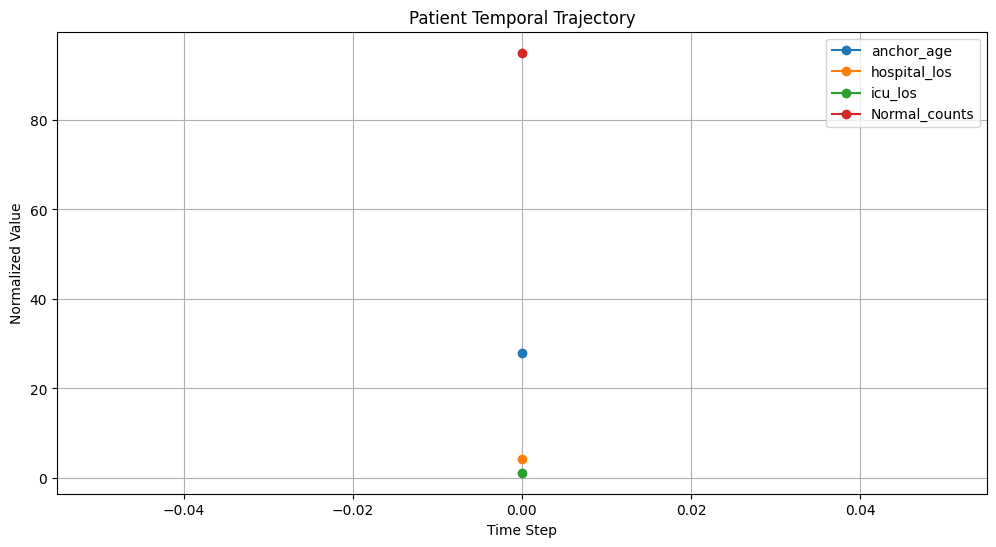

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

patient_df = pd.DataFrame(patient_x, columns=feature_cols)

# safe mask
valid_idx = np.array(patient_mask).astype(bool)

print("patient_x shape:", patient_x.shape)
print("valid timesteps:", valid_idx.sum())

# if mask removes everything, do not filter
if valid_idx.sum() > 0:
    patient_df = patient_df.loc[valid_idx].reset_index(drop=True)
else:
    print("Mask empty, plotting full sequence")

print("patient_df shape:", patient_df.shape)
print(patient_df.head())

plt.figure(figsize=(12,6))

for col in patient_df.columns[:4]:
    plt.plot(
        patient_df.index,
        patient_df[col],
        marker='o',
        label=col
    )

plt.xlabel("Time Step")
plt.ylabel("Normalized Value")
plt.title("Patient Temporal Trajectory")
plt.legend()
plt.grid(True)
plt.show()

##Generate table output

In [ ]:
import pandas as pd

if "results" not in globals():
    raise Exception("Run the what-if prediction cell first.")

summary_rows = []
for tr, prob in results.items():
    summary_rows.append({
        "Simulated Treatment": treatment_mapping.get(tr, f"Treatment {tr}"),
        "Predicted Risk Probability": round(float(prob), 4),
        "Predicted Outcome": "High Risk" if prob >= 0.5 else "Low Risk"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="Predicted Risk Probability").reset_index(drop=True)
summary_df


##Important interpretation notes

- The model predicts mortality risk from observed EHR sequence features.
- The what-if section changes the treatment label sequence and observes how the trained model prediction changes.
- This is **not** a causal treatment recommendation system yet.
- For true causal counterfactuals, add confounder adjustment methods such as propensity scores, inverse probability weighting, marginal structural models, causal forests, or targeted maximum likelihood estimation.
